In [1]:
import pandas as pd
import numpy as np
%pip install seaborn
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

Matplotlib is building the font cache; this may take a moment.


In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import precision_recall_fscore_support as prf_score
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV

In [3]:
heart = pd.read_csv('data/heart_disease.csv')
heart

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [4]:
heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 68.2+ KB


In [5]:
heart.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [6]:
heart.select_dtypes(include = ['object']).nunique()

Sex               2
ChestPainType     4
RestingECG        3
ExerciseAngina    2
ST_Slope          3
dtype: int64

In [7]:
heart['Sex'] = heart['Sex'].map({'M': 1, 'F': 0})
heart['ExerciseAngina'] = heart['ExerciseAngina'].map({'Y': 1, 'N': 0})

heart = pd.get_dummies(heart, columns = ['ChestPainType','RestingECG','ST_Slope'], dtype = int, drop_first=True)

cols = [col for col in heart.columns if col != 'HeartDisease'] + ['HeartDisease']
heart = heart[cols]

In [8]:
heart

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up,HeartDisease
0,40,1,140,289,0,172,0,0.0,1,0,0,1,0,0,1,0
1,49,0,160,180,0,156,0,1.0,0,1,0,1,0,1,0,1
2,37,1,130,283,0,98,0,0.0,1,0,0,0,1,0,1,0
3,48,0,138,214,0,108,1,1.5,0,0,0,1,0,1,0,1
4,54,1,150,195,0,122,0,0.0,0,1,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,1,110,264,0,132,0,1.2,0,0,1,1,0,1,0,1
914,68,1,144,193,1,141,0,3.4,0,0,0,1,0,1,0,1
915,57,1,130,131,0,115,1,1.2,0,0,0,1,0,1,0,1
916,57,0,130,236,0,174,0,0.0,1,0,0,0,0,1,0,1


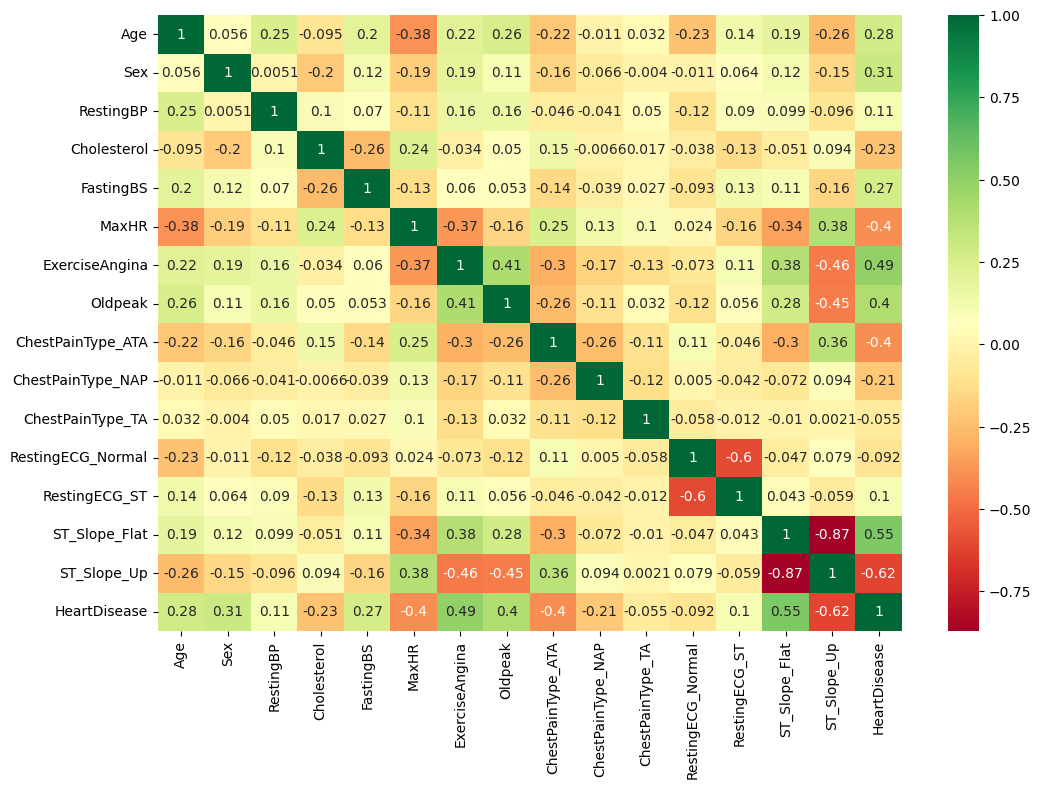

In [9]:
heart_corr = heart.corr()
plt.figure(figsize=(12,8))
sns.heatmap(heart_corr, annot=True, cmap='RdYlGn')
plt.show()

In [10]:
heart['HeartDisease'].value_counts()

HeartDisease
1    508
0    410
Name: count, dtype: int64

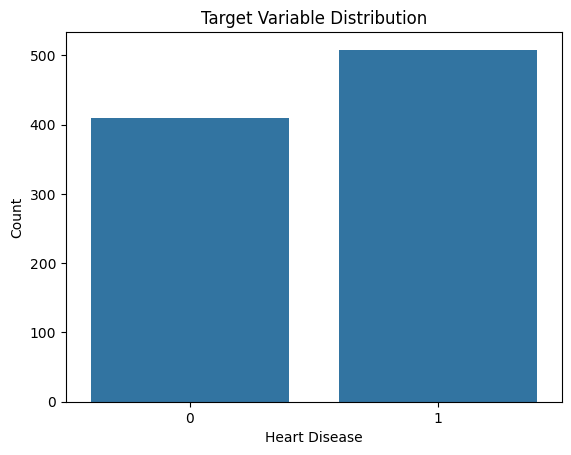

In [11]:
sns.countplot(x='HeartDisease', data=heart)
plt.title('Target Variable Distribution')
plt.xlabel('Heart Disease')
plt.ylabel('Count')
plt.show()

In [12]:
X = heart.drop('HeartDisease', axis=1)
Y = heart['HeartDisease']

In [13]:
rs = 42

In [14]:
sss = StratifiedShuffleSplit(n_splits=1,
                             test_size=0.25,
                             random_state=rs)

for train_index, test_index in sss.split(X, Y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    Y_train, Y_test = Y.iloc[train_index], Y.iloc[test_index]

In [15]:
print(Y_train.value_counts(normalize=True))
print(Y_test.value_counts(normalize=True))

HeartDisease
1    0.553779
0    0.446221
Name: proportion, dtype: float64
HeartDisease
1    0.552174
0    0.447826
Name: proportion, dtype: float64


In [16]:
scores = pd.DataFrame(columns=['Model','Accuracy','Precision','Recall','F1'])

In [17]:
def get_scores(model, Y_test, Y_pred):
    acc = accuracy_score(Y_test, Y_pred)
    p, r, f, _ = prf_score(Y_test, Y_pred, average='binary')
    print("F1 score for", model, " - ", f)
    scores.loc[len(scores)] = [model, acc, p, r, f]

In [18]:
def plot_cm(mod_labels, models):
    fig, axList = plt.subplots(nrows=1, ncols=len(mod_labels))
    axList = axList.flatten()
    fig.set_size_inches(12, 4)

    for ax,lab,mod in zip(axList, mod_labels, models):
        Y_pred = mod.predict(X_test_ss)
        sns.heatmap(confusion_matrix(Y_test,Y_pred), ax=ax, annot=True, fmt='d', annot_kws={"size": 15}, cmap='crest');
        ax.set_ylabel('Prediction', fontsize=15);
        ax.set_xlabel('Ground Truth', fontsize=15);
        ax.set(title=lab);
    
    plt.tight_layout()

In [19]:
ss = StandardScaler()

X_train_ss = ss.fit_transform(X_train)
X_test_ss = ss.transform(X_test)

In [20]:
lr = LogisticRegression(solver='lbfgs',penalty=None)
lr.fit(X_train_ss, Y_train)

lr_l1 = LogisticRegressionCV(solver='liblinear', penalty='l1', cv=3, Cs=10)
lr_l1.fit(X_train_ss, Y_train)

lr_l2 = LogisticRegressionCV(solver='liblinear', penalty='l2', cv=3, Cs=10)
lr_l2.fit(X_train_ss, Y_train)

LogisticRegressionCV(cv=3, solver='liblinear')

In [21]:
mod_labels = ['Logistic Regression', 'LR with L1 Regularization', 'LR with L2 Regularization']
models = [lr, lr_l1, lr_l2]

for lab, mod in zip(mod_labels, models):
    Y_pred = mod.predict(X_test_ss)
    get_scores(lab, Y_test, Y_pred)

F1 score for Logistic Regression  -  0.896551724137931
F1 score for LR with L1 Regularization  -  0.896551724137931
F1 score for LR with L2 Regularization  -  0.8852459016393442


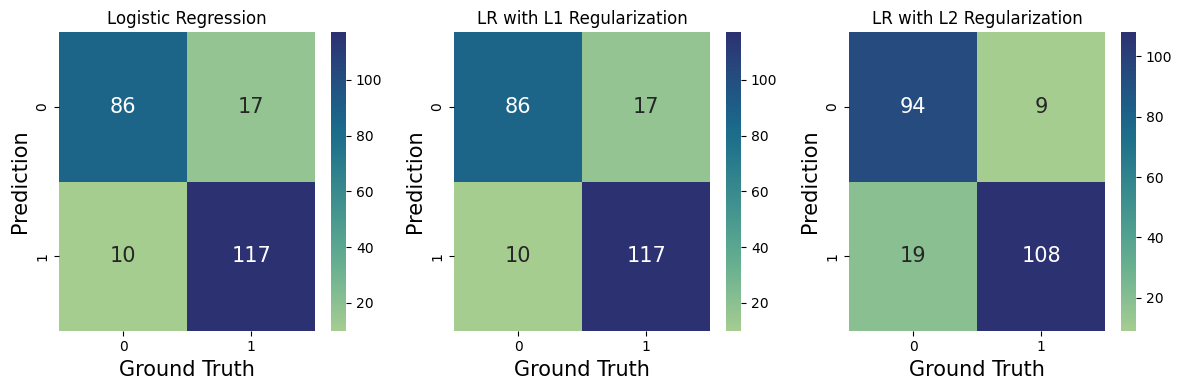

In [22]:
plot_cm(mod_labels, models)

In [23]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_ss, Y_train)
Y_pred = knn.predict(X_test_ss)
get_scores('K-Nearest Neighbors', Y_test, Y_pred)

f1_scores = list()
f1_best = 0
for k in range(3,36,2):
    knn_k = KNeighborsClassifier(n_neighbors=k, weights='distance')
    knn_k = knn_k.fit(X_train_ss, Y_train)
    Y_pred = knn_k.predict(X_test_ss)
    f1 = f1_score(Y_pred, Y_test)
    f1_scores.append((k, round(f1, 6)))
    if (f1 > f1_best):
        f1_best = f1
        knn_best = knn_k
        k_best = k
        Y_pred_best = Y_pred
print("Best K = ", k_best)
get_scores('Weighted k-NN with Tuned Params', Y_test, Y_pred_best)

f1_results = pd.DataFrame(f1_scores, columns=['K', 'F1 Score'])

F1 score for K-Nearest Neighbors  -  0.90625
Best K =  21
F1 score for Weighted k-NN with Tuned Params  -  0.9254901960784314


Text(0.5, 1.0, 'k-NN F1 Scores')

<Figure size 1920x1440 with 0 Axes>

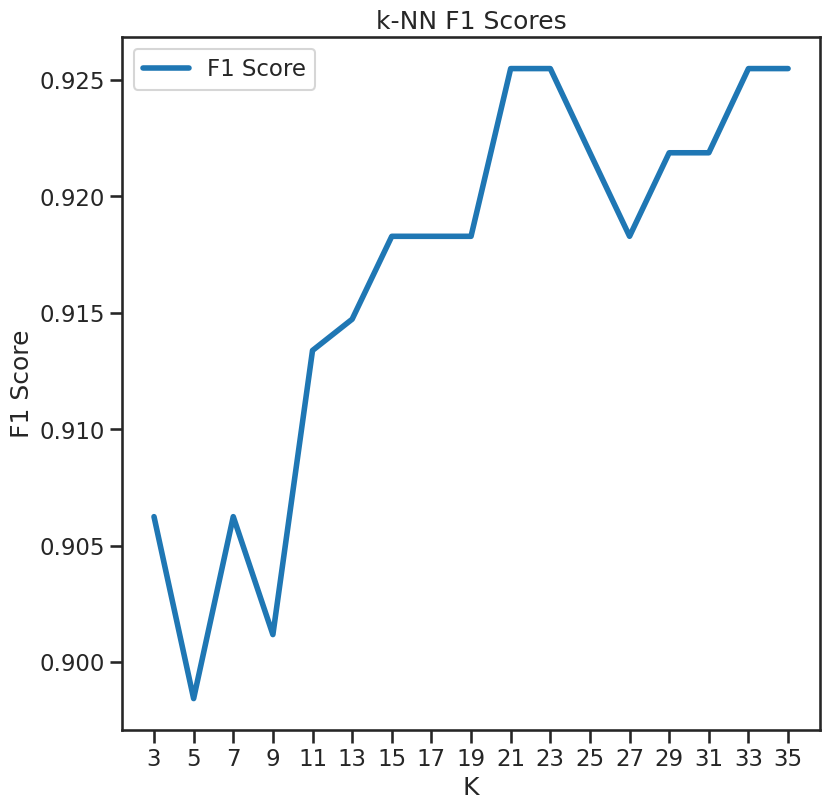

In [24]:
sns.set_context('talk')
sns.set_style('ticks')

plt.figure(dpi=300)
ax = f1_results.set_index('K').plot(figsize=(9, 9), linewidth=4)
ax.set(xlabel='K', ylabel='F1 Score')
ax.set_xticks(range(3, 36, 2));
plt.title('k-NN F1 Scores')

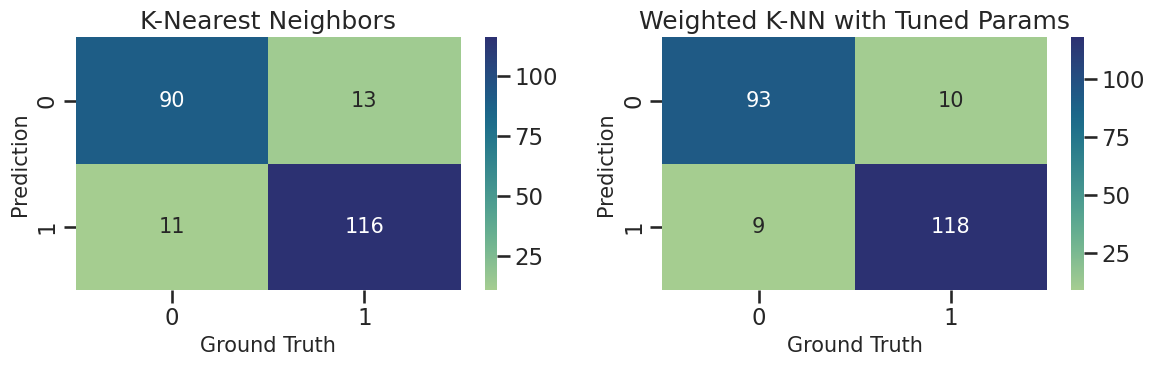

In [25]:
mod_labels = ['K-Nearest Neighbors', 'Weighted K-NN with Tuned Params']
models = [knn, knn_best]

plot_cm(mod_labels, models)

In [26]:
lsvc = LinearSVC()
lsvc.fit(X_train_ss, Y_train)
Y_pred = lsvc.predict(X_test_ss)
get_scores('Linear Support Vector Machine', Y_test, Y_pred)

gammas = [0.01, 0.05, 0.1, 0.5]
Cs = [0.01, 0.1, 1, 10]
f1_best = 0
svm_best_params = list()
for gamma in gammas:
    for C in Cs:
        svcg = SVC(kernel = 'rbf', gamma = gamma, C = C)
        svcg.fit(X_train_ss, Y_train)
        Y_pred = svcg.predict(X_test_ss)
        f1 = f1_score(Y_pred, Y_test)
        if (f1 > f1_best):
            f1_best = f1
            svcg_best = svcg
            svm_best_params = [gamma, C]
            Y_pred_best = Y_pred
print("Best params: ", svm_best_params)
get_scores('SVM with Tuned Params', Y_test, Y_pred_best)

F1 score for Linear Support Vector Machine  -  0.9
Best params:  [0.1, 1]
F1 score for SVM with Tuned Params  -  0.9166666666666666


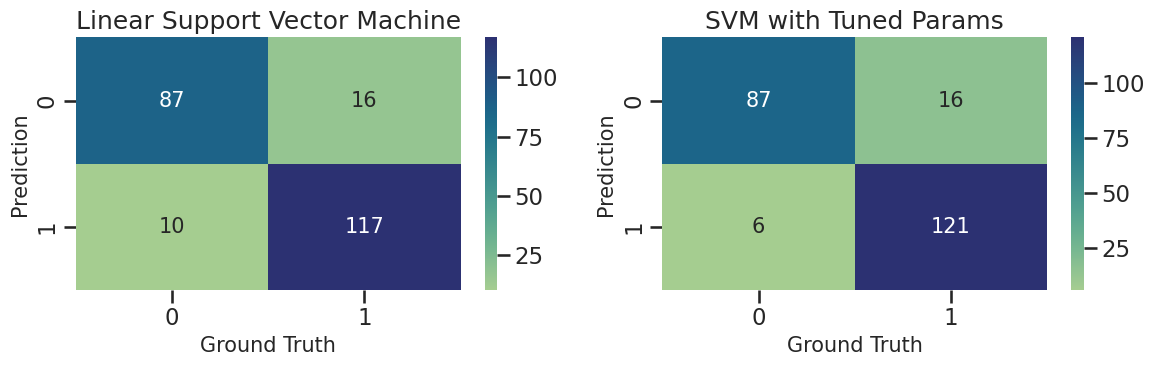

In [27]:
mod_labels = ['Linear Support Vector Machine', 'SVM with Tuned Params']
models = [lsvc, svcg_best]

plot_cm(mod_labels, models)

In [28]:
dtree = DecisionTreeClassifier(random_state=rs)
dtree.fit(X_train_ss, Y_train)
Y_pred = dtree.predict(X_test_ss)
get_scores('Decision Tree', Y_test, Y_pred)

tree_depth = dtree.tree_.max_depth

F1 score for Decision Tree  -  0.8221343873517787


In [29]:
param_grid = {'max_depth': range(3, tree_depth, 2),
              'max_features': [3,5,7,9,11]}

gridcv = GridSearchCV(DecisionTreeClassifier(random_state=rs),
                      param_grid = param_grid,
                      scoring = 'f1',
                      n_jobs = -1,
                      cv = 4,
                      verbose = 1)

gridcv.fit(X_train_ss, Y_train)
print("Number of nodes = ", gridcv.best_estimator_.tree_.node_count)
best_depth = gridcv.best_params_['max_depth']
best_feat = gridcv.best_params_['max_features']
gridcv.best_params_

Fitting 4 folds for each of 25 candidates, totalling 100 fits
Number of nodes =  15


{'max_depth': 3, 'max_features': 9}

In [30]:
Y_pred = gridcv.predict(X_test_ss)
get_scores('DT with Tuned Params', Y_test, Y_pred)

F1 score for DT with Tuned Params  -  0.8663967611336032


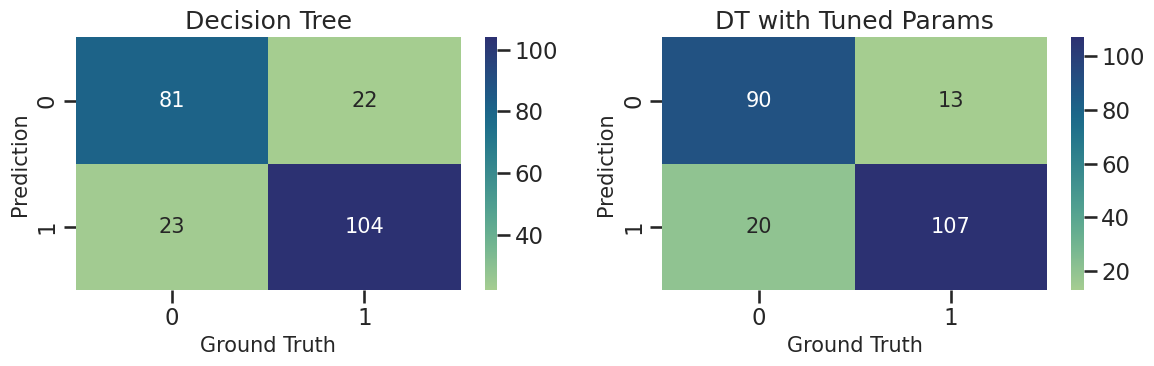

In [31]:
mod_labels = ['Decision Tree', 'DT with Tuned Params']
models = [dtree, gridcv]

plot_cm(mod_labels, models)

In [32]:
rf = RandomForestClassifier(oob_score = True,
                            random_state = rs,
                            warm_start = True,
                            n_jobs = -1)

oob_errors = list()
oob_min = 1.0
tree_number = [25,50,75,100,125,150,175,200,250,300,350,400]
for n_trees in tree_number:
    rf.set_params(n_estimators = n_trees)
    rf.fit(X_train_ss, Y_train)
    oob_error = 1 - rf.oob_score_
    oob_errors.append(pd.Series({'No. of trees':n_trees, 'Out-of-bag error':oob_error}))
    if (oob_error < oob_min):
        oob_min = oob_error
        n_tree_rf_best = n_trees

rf_oob_df = pd.concat(oob_errors, axis=1).T.set_index('No. of trees')

In [33]:
et = ExtraTreesClassifier(oob_score = True,
                          bootstrap = True,
                          random_state = rs,
                          warm_start = True,
                          n_jobs = -1)

oob_errors = list()
oob_min = 1.0
tree_number = [25,50,75,100,125,150,175,200,250,300,350,400]
for n_trees in tree_number:
    et.set_params(n_estimators = n_trees)
    et.fit(X_train_ss, Y_train)
    oob_error = 1 - et.oob_score_
    oob_errors.append(pd.Series({'No. of trees':n_trees, 'Out-of-bag error':oob_error}))
    if (oob_error < oob_min):
        oob_min = oob_error
        n_tree_et_best = n_trees

et_oob_df = pd.concat(oob_errors, axis=1).T.set_index('No. of trees')

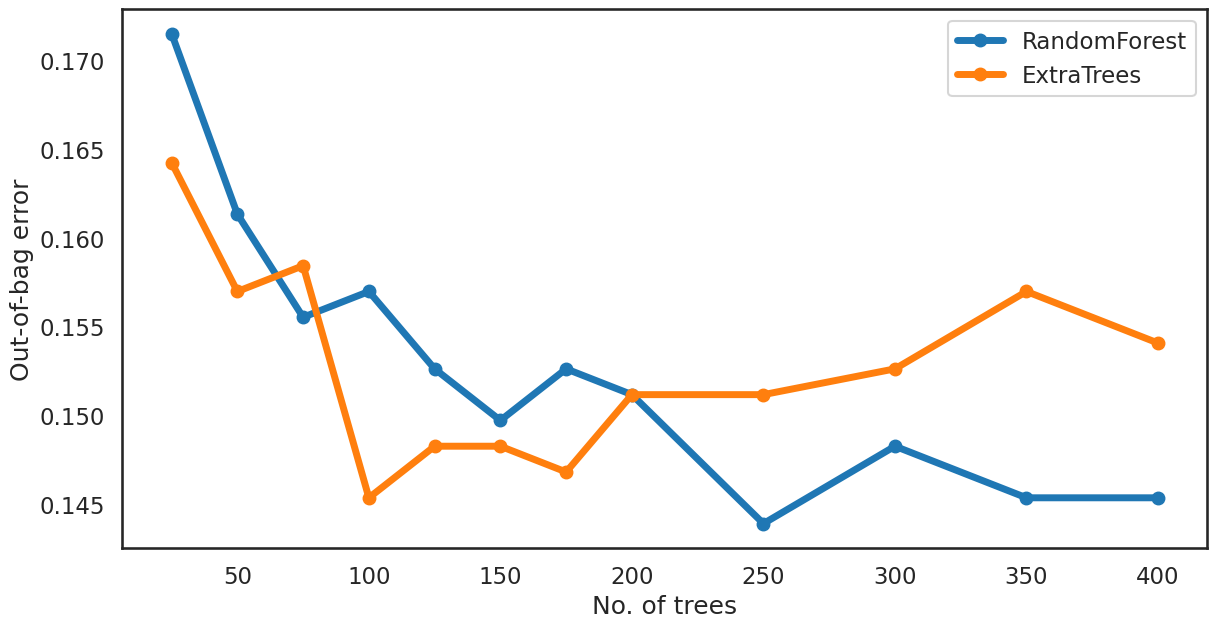

In [34]:
oob_df = pd.concat([rf_oob_df.rename(columns={'Out-of-bag error':'RandomForest'}),
                    et_oob_df.rename(columns={'Out-of-bag error':'ExtraTrees'})], axis=1)

sns.set_context('talk')
sns.set_style('white')
ax = oob_df.plot(marker='o', figsize=(14, 7), linewidth=5)
ax.set(ylabel='Out-of-bag error');

In [35]:
rf_best = rf.set_params(n_estimators = n_tree_rf_best)
Y_pred = rf_best.predict(X_test_ss)
get_scores('Random Forest', Y_test, Y_pred)

et_best = et.set_params(n_estimators = n_tree_et_best)
Y_pred = et_best.predict(X_test_ss)
get_scores('Extra Random Trees', Y_test, Y_pred)

F1 score for Random Forest  -  0.9105058365758755
F1 score for Extra Random Trees  -  0.9083969465648855


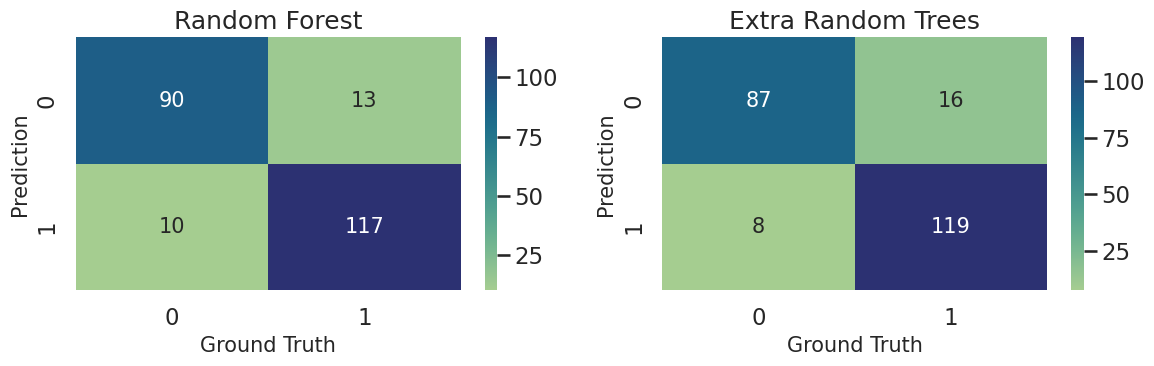

In [36]:
mod_labels = ['Random Forest', 'Extra Random Trees']
models = [rf_best, et_best]

plot_cm(mod_labels, models)

In [37]:
gradboost = GradientBoostingClassifier(random_state = rs)

param_grid_grad = {'n_estimators': [150,200,300],
                   'max_features': [3,4,5],
                   'learning_rate': [0.001,0.01,0.1],
                   'subsample': [1.0,0.8]}
gradcv = GridSearchCV(gradboost,
                      param_grid = param_grid_grad,
                      scoring = 'f1',
                      n_jobs = -1,
                      verbose = 1)
gradcv.fit(X_train_ss, Y_train)
grad_lr = gradcv.best_params_['learning_rate']
grad_est = gradcv.best_params_['n_estimators']
grad_feat = gradcv.best_params_['max_features']
grad_sub = gradcv.best_params_['subsample']
gradcv.best_estimator_, gradcv.best_params_

Fitting 5 folds for each of 54 candidates, totalling 270 fits


(GradientBoostingClassifier(learning_rate=0.01, max_features=5, n_estimators=300,
                            random_state=42),
 {'learning_rate': 0.01,
  'max_features': 5,
  'n_estimators': 300,
  'subsample': 1.0})

In [38]:
adaboost = AdaBoostClassifier(random_state = rs)

param_grid_ada = {'n_estimators': [50,80,100,150,200],
                  'learning_rate': [0.1,0.5,1.0]}
adacv = GridSearchCV(adaboost,
                     param_grid = param_grid_ada,
                     scoring = 'f1',
                     n_jobs = -1,
                     verbose = 1)
adacv.fit(X_train_ss, Y_train)
ada_lr = adacv.best_params_['learning_rate']
ada_est = adacv.best_params_['n_estimators']
adacv.best_estimator_, adacv.best_params_

Fitting 5 folds for each of 15 candidates, totalling 75 fits


(AdaBoostClassifier(learning_rate=0.5, n_estimators=150, random_state=42),
 {'learning_rate': 0.5, 'n_estimators': 150})

In [39]:
Y_pred = gradcv.predict(X_test_ss)
get_scores('Gradient Boosting', Y_test, Y_pred)

Y_pred = adacv.predict(X_test_ss)
get_scores('AdaBoost', Y_test, Y_pred)

F1 score for Gradient Boosting  -  0.918918918918919
F1 score for AdaBoost  -  0.8968253968253969


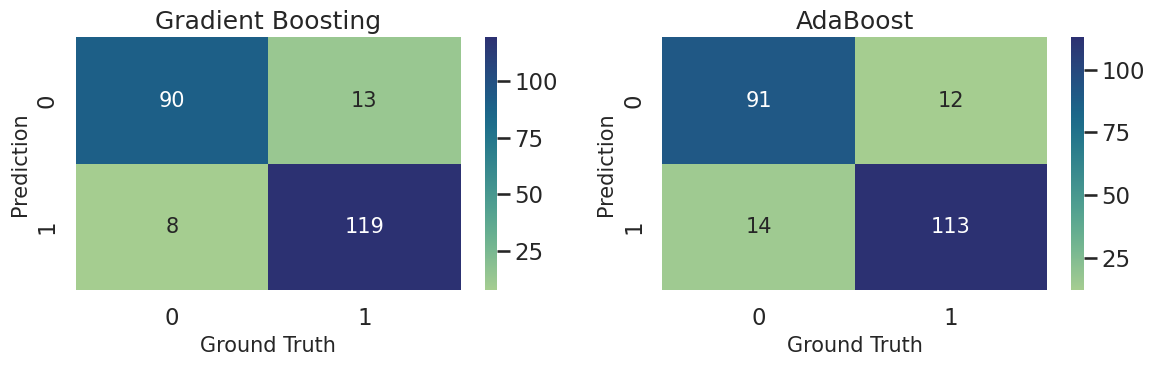

In [40]:
mod_labels = ['Gradient Boosting', 'AdaBoost']
models = [gradcv, adacv]

plot_cm(mod_labels, models)

In [41]:
estimators = [('k-NN', KNeighborsClassifier(n_neighbors = k_best, weights = 'distance')),
              ('SVM', SVC(kernel = 'rbf', gamma = svm_best_params[0], C = svm_best_params[1])), 
              ('Decision Trees', DecisionTreeClassifier(max_depth = best_depth, max_features = best_feat, random_state = rs)),
              ('Extra Random Trees', ExtraTreesClassifier(bootstrap = True, random_state = rs,  warm_start = True, n_jobs = -1, n_estimators = n_tree_et_best)),
              ('GradBoost', GradientBoostingClassifier(random_state = rs, learning_rate = grad_lr, n_estimators = grad_est, max_features = grad_feat, subsample = grad_sub))]

stack = StackingClassifier(estimators = estimators,
                           final_estimator = LogisticRegression(solver='liblinear', random_state = rs),
                           cv=StratifiedKFold(n_splits = 5, shuffle = True, random_state = rs), 
                           n_jobs = -1,
                           verbose = 1)
stack.fit(X_train_ss, Y_train)

StackingClassifier(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimators=[('k-NN',
                                KNeighborsClassifier(n_neighbors=21,
                                                     weights='distance')),
                               ('SVM', SVC(C=1, gamma=0.1)),
                               ('Decision Trees',
                                DecisionTreeClassifier(max_depth=3,
                                                       max_features=9,
                                                       random_state=42)),
                               ('Extra Random Trees',
                                ExtraTreesClassifier(bootstrap=True, n_jobs=-1,
                                                     random_state=42,
                                                     warm_start=True)),
                               ('GradBoost',
                                GradientBoostingClassifier(learning_rate=0.01,
                                                           max_features=5,
                                                           n_estimators=300,
                                                           random_state=42))],
                   final_estimator=LogisticRegression(random_state=42,
                                                      solver='liblinear'),
                   n_jobs=-1, verbose=1)

In [42]:
Y_pred = stack.predict(X_test_ss)
get_scores('Stacking', Y_test, Y_pred)

F1 score for Stacking  -  0.918918918918919


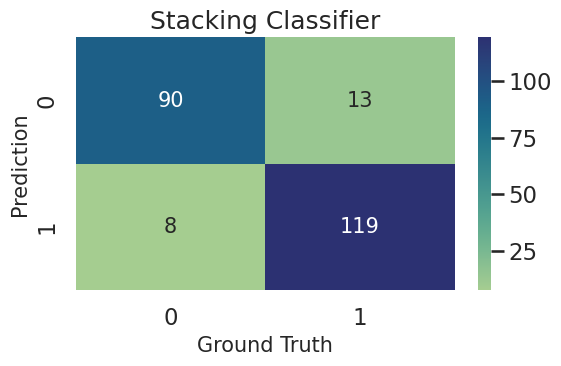

In [43]:
fig, ax = plt.subplots(nrows=1, ncols=1)
fig.set_size_inches(6, 4)

sns.heatmap(confusion_matrix(Y_test,Y_pred), annot=True, fmt='d', annot_kws={"size": 15}, cmap='crest');
ax.set_ylabel('Prediction', fontsize=15);
ax.set_xlabel('Ground Truth', fontsize=15);
ax.set(title='Stacking Classifier');

plt.tight_layout()

In [44]:
scores

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.882609,0.873134,0.921260,0.896552
1,LR with L1 Regularization,0.882609,0.873134,0.921260,0.896552
2,LR with L2 Regularization,0.878261,0.923077,0.850394,0.885246
3,K-Nearest Neighbors,0.895652,0.899225,0.913386,0.906250
4,Weighted k-NN with Tuned Params,0.917391,0.921875,0.929134,0.925490
5,Linear Support Vector Machine,0.886957,0.879699,0.921260,0.900000
6,SVM with Tuned Params,0.904348,0.883212,0.952756,0.916667
7,Decision Tree,0.804348,0.825397,0.818898,0.822134
8,DT with Tuned Params,0.856522,0.891667,0.842520,0.866397
9,Random Forest,0.900000,0.900000,0.921260,0.910506
